# Chapter 6: 学習に関するテクニック（後半 p.186〜）

## 6章前半の復習

➡️ 後半に影響する部分に絞る

6.2 重みの初期値 \
重みの初期値を適切に設定すれば、各層のアクティベーションの分布は適切な広がりを持ち、学習がスムーズに行える

## 6.3 Batch Normalization

### 6.3.1 Batch Normalizationのアルゴリズム

Batch Normalization ... ミニバッチごとに正規化すること
- Batch(バッチ) ... まとまりのある入力データ（p.79 3.6.3 バッチ処理より）
- Normalization(正規化) ... データの分布を、平均0・分散1に変換すること

ミニバッチの入力データ $B = \{ x_1, x_2, \dots, x_m \}$ を、 \
平均0・分散1のデータ $\hat{B} = \{ \hat{x}_1, \hat{x}_2, \dots, \hat{x}_m \}$ に変換する

1. 平均 $\mu_B$ を求める
$$
\mu_B ← \frac{1}{m} \sum_{i=1}^{m} x_i
$$

2. 分散 $\sigma_B^2$ を求める
$$
\sigma_B^2 ← \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2
$$

3. 正規化（平均0、分散1に変換）
    $$
    \hat{x}_i ← \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}}
    $$
    ※ $\varepsilon$ は、小さな値（例：10e-7など）で、0での除算を防止する為のもの

4. 固有のスケール $\gamma$ とシフト $\beta$ で変換
    $$
    y_i = \gamma \hat{x}_i + \beta
    $$
    最初は $\gamma = 1$ とシフト $\beta = 0$ からスタートして、学習によって適した値に調整

利点
- 学習を早く進行させることができる（学習係数を大きくすることができる）
- 初期値にそれほど依存しない（初期値に対してそこまで神経質にならなくて良い）
- 過学習を抑制する（Dropoutなどの必要性を減らす）

```mermaid
flowchart LR

classDef bn fill:#e6e6e6,stroke:#000,color:#000;

subgraph Layer1
A1[Affine] --> BN1[Batch Norm] --> R1[ReLU]
end

subgraph Layer2
A2[Affine] --> BN2[Batch Norm] --> R2[ReLU]
end

subgraph Layer3
A3[Affine]
end

R1 --> A2
R2 --> A3
A3 --> SM[Softmax]

class BN1,BN2 bn;
```

➡️ Q. なぜこの処理を行うか / どういう時にこれを使うかの説明

参考：https://www.anarchive-beta.com/entry/2020/08/16/180000

参考：https://data-analytics.fun/2021/09/11/understanding-batch-normalization/

### 6.3.2 Batch Normalizationの評価

MNISTデータセットを使って、Batch Normレイヤを用いるときと用いないときで、学習の進みがどう変わるかをみてみる

Batch Normによって学習が速く進んでいることが分かる

#### ch06/batch_norm_test.py

重みの初期値の標準偏差をさまざまな値に変えたとき、学習がどのように変化するか

/var/folders/h6/n92v7d9d5t99qsmn8zrqpm540000gn/T/ipykernel_67365/3836009115.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


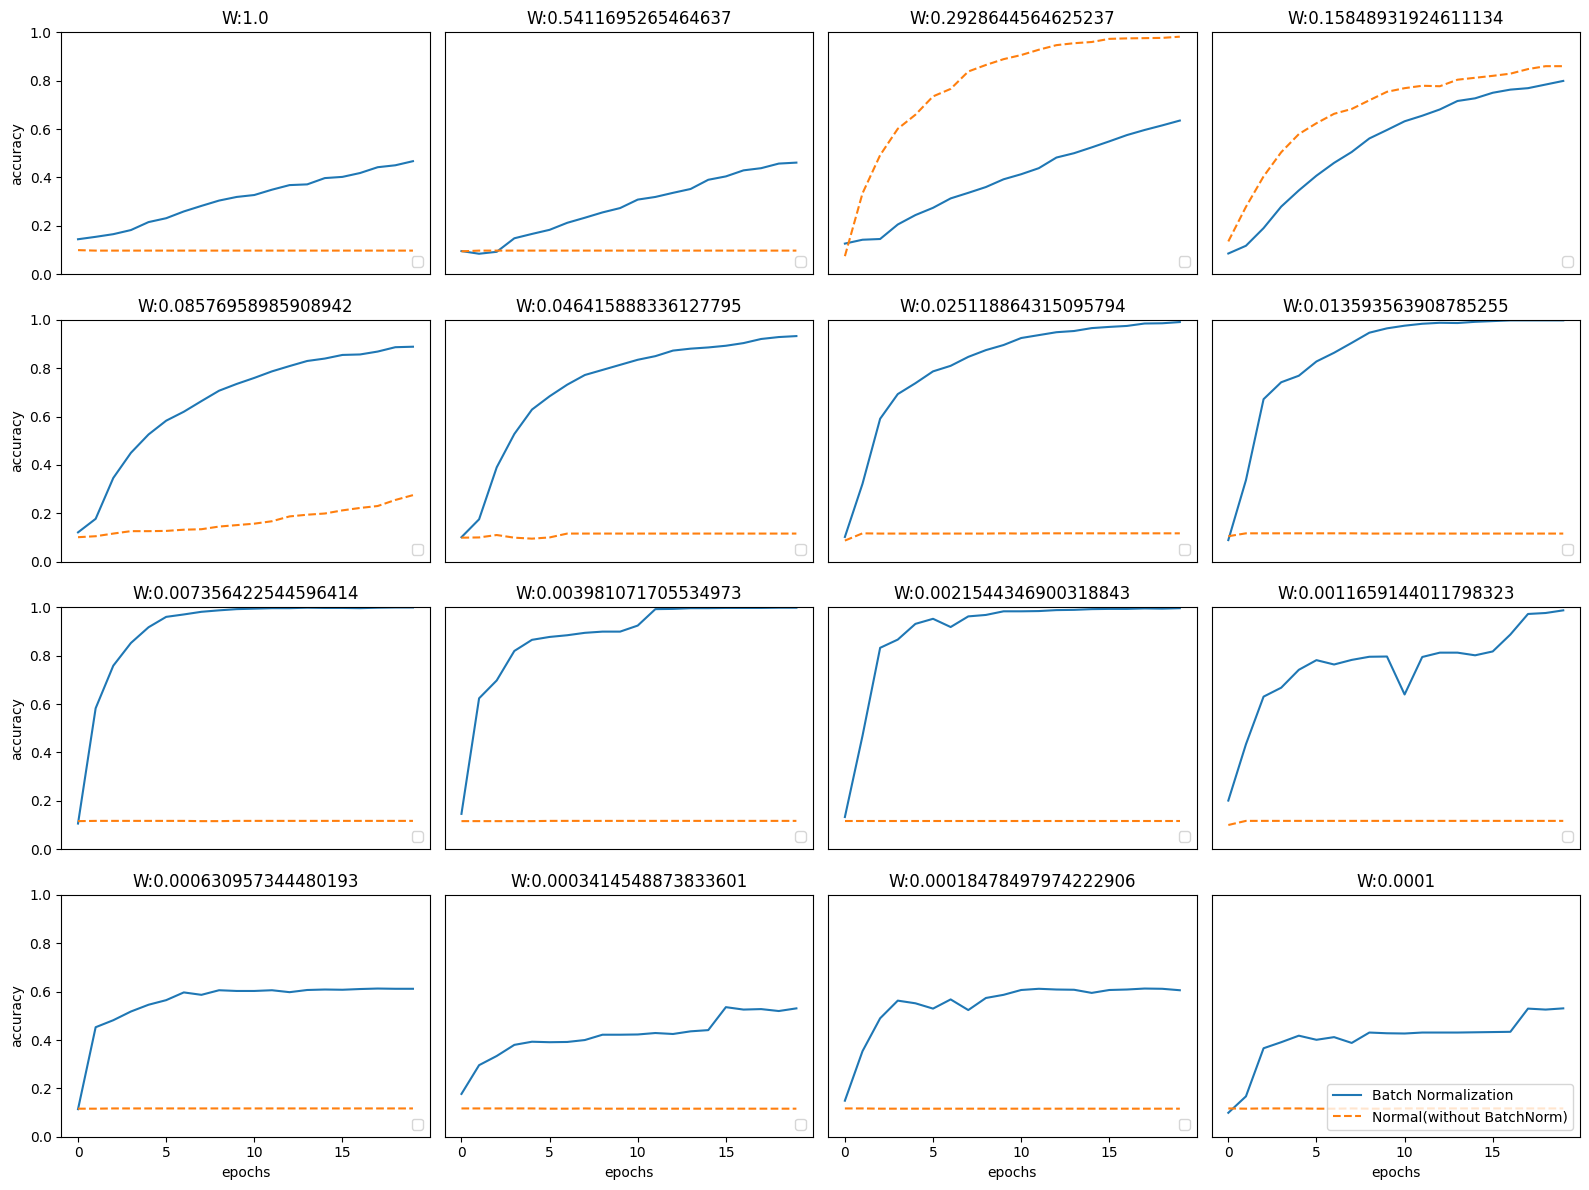

In [4]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 学習データを削減
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            # print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 3.グラフの描画==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

plt.figure(figsize=(16, 12)) # 追記

for i, w in enumerate(weight_scale_list):
    # print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')
    
plt.tight_layout() # 追記
plt.show()

- 実線 ... Batch Normを使用した場合の結果
- 点線 ... Batch Normを使用しなかった場合の結果

ほとんど全てのケースでBatch Normを使用した方が学習の進みが速い
Batch Normを用いない場合は、良い初期値のスケールを与えないと、全く学習が進まない

Batch Normを使用することで、学習の進行を促進させることができ、また、重みの初期値にロバストに(それほど依存しなく)なる

## 6.4 正則化

過学習（overfitting）...  \
訓練データだけに適応しすぎてしまい、訓練データに含まれない他のデータにはうまく対応できない状態

機械学習では汎化性能の高いモデルが望まれる為、過学習を抑制するテクニックが重要になる

### 6.4.1 過学習

過学習が起きる原因
1. パラメータを大量に持ち、表現力の高いモデルであること
2. 訓練データが少ないこと

ここでは、この2つの要件をわざと満たして、過学習を発生させる
1. 7層のネットワークー各層のニューロンの個数は100個、活性化関数はReLUを使う（ネットワークの複雑性を高めるため）
2. MNISTデータセットの訓練データを本来の60,000個から300個に限定

#### ch06/overfit_weight_decay.py

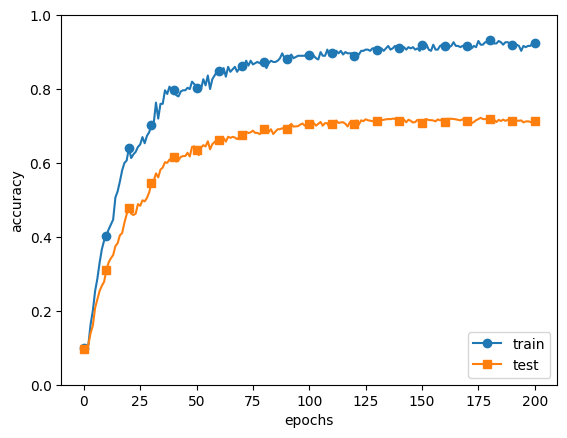

In [6]:
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（荷重減衰）の設定 =======================
#weight_decay_lambda = 0 # weight decayを使用しない場合
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
# 以下2つには、エポック単位(全ての訓練データを見終わった単位)の認識精度が格納される
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        # print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

- train(訓練データを用いて計測した認識精度)：100エポックを過ぎたあたりからほとんど100%
- test：100%の認識精度からは大きな隔たり←訓練データに適応し過ぎてしまった結果

### 6.4.2 Weight decay

過学習抑制のために昔からよく用いられる手法に「Weight decay」という手法がある

Weight decay（荷重減衰）... \
学習の過程において、大きな重みを持つことに対してペナルティを課すことで、過学習を抑制しようというもの \
※ そもそも過学習は重みパラメータが大きな値を取ることで発生することが多くある

ニューラルネットワークの学習は、損失関数（必要に応じて正則化項を含む）を最小化する問題として定式化できる

損失関数を $L(\mathbf{w})$、正則化項を $\lambda \lVert \mathbf{w} \rVert_p$ とすると、

| | 最小化問題 |
|---|---|
| **過学習対策なし** | $\min_{\mathbf{w}} L(\mathbf{w})$ |
| **正則化による過学習対策 ※** | $\min_{\mathbf{w}} \left( L(\mathbf{w}) + \lambda \lVert \mathbf{w} \rVert_p \right)$ |

※ 解析上扱いやすい形として $\lambda \lVert \mathbf{w} \rVert_p^p$ を用いることもある。特に L2 では通常 $\lVert \mathbf{w} \rVert_2^2$ を用いる。

※ $\min_{\mathbf{w}} L(\mathbf{w})$ は、「wを変数として最小化する」の意味
> 例えば
> $$
> \min_{\mathbf{w},\,\lambda}
> \; L(\mathbf{w}) + \lambda \lVert \mathbf{w} \rVert_2^2
> $$
> → 「$\mathbf{w}$ と $\lambda$ の両方を動かして最小化する」の意味 \
> ※ 今回は例として出しているが、通常 λ は固定されたハイパーパラメータであり、実際の最適化は w についてのみ行う
> 
> $$
> \min_{\mathbf{w}}
> \; L(\mathbf{w}) + \lambda \lVert \mathbf{w} \rVert_2^2
> $$
> → 「$\lambda$ は固定して、$\mathbf{w}$ についてのみ最小化する」の意味

正則化項として用いれるもの

参考：https://toeming.hatenablog.com/entry/2020/04/03/000925

L1ノルム(マンハッタン距離) ... 絶対値の和

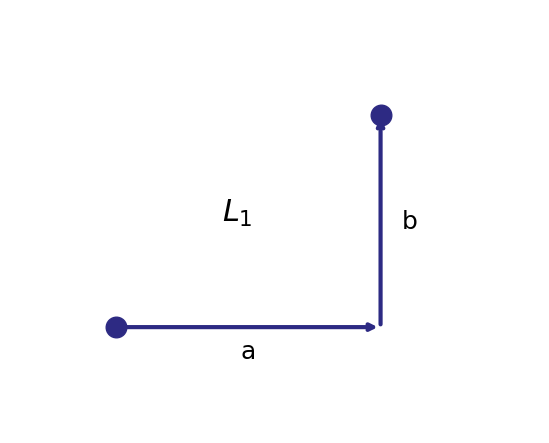

L2ノルム(ユークリッド距離) ... 各要素の2乗和 ←一般的によく用いられる

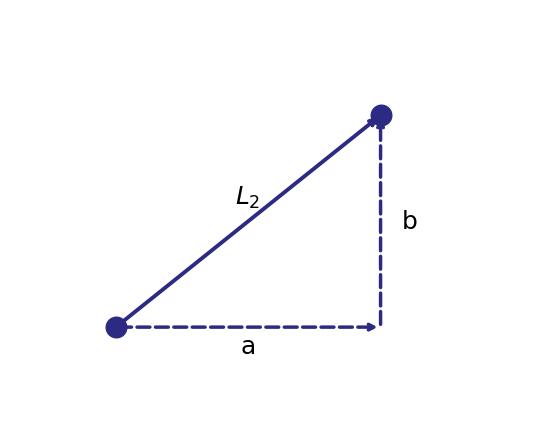

L∞ノルム(Maxノルム) ... 各要素の絶対値の中で最大のもの

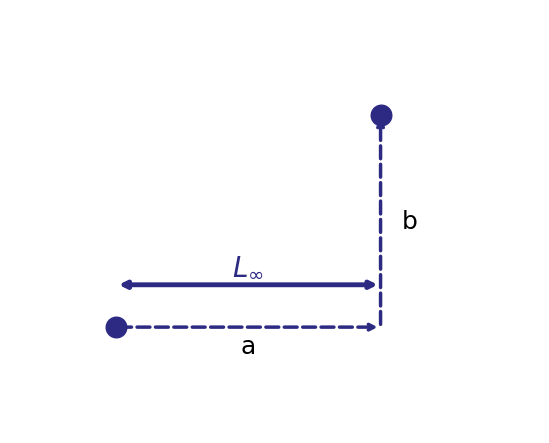

参考：https://toukei-lab.com/euclidean-manhattan-distance#L1

ニューラルネットワークの学習は、損失関数の値を小さくすることを目的として行われる \
→損失関数に、重みの2乗ノルム（L2ノルム）を加算すると、重みが大きくなることを抑えられる

### 6.4.3 Dropout

#### ch06/overfit_dropout.py

train loss:2.306975946889085
=== epoch:1, train acc:0.10333333333333333, test acc:0.1049 ===
train loss:2.309044746734719
train loss:2.300197138914193
train loss:2.2899364208250144
=== epoch:2, train acc:0.10333333333333333, test acc:0.1078 ===
train loss:2.299351697213905
train loss:2.298579211918337
train loss:2.30033972809789
=== epoch:3, train acc:0.10333333333333333, test acc:0.1084 ===
train loss:2.298407722243274
train loss:2.290574548807106
train loss:2.2910548846749506
=== epoch:4, train acc:0.11333333333333333, test acc:0.1092 ===
train loss:2.300846571325947
train loss:2.291865408690855
train loss:2.290360587823036
=== epoch:5, train acc:0.11666666666666667, test acc:0.1106 ===
train loss:2.2935854359351695
train loss:2.2860466184842587
train loss:2.28443588064665
=== epoch:6, train acc:0.11333333333333333, test acc:0.1116 ===
train loss:2.2806688119504157
train loss:2.289689215478857
train loss:2.288062519098229
=== epoch:7, train acc:0.11, test acc:0.1132 ===
train loss:2.

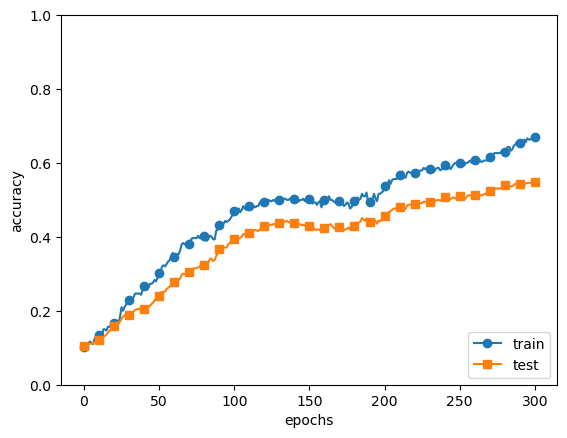

In [8]:
import os
import sys
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# Dropuoutの有無、割り合いの設定 ========================
use_dropout = True  # Dropoutなしのときの場合はFalseに
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

## 6.5 ハイパーパラメータの検証

### 6.5.1 検証データ

### 6.5.2 ハイパーパラメータの最適化

### 6.5.3 ハイパーパラメータ最適化の実装

#### ch06/hyperparameter_optimization.py

val acc:0.09 | lr:1.901967382287021e-06, weight decay:1.3286113794384553e-06
val acc:0.6 | lr:0.003978766790506623, weight decay:1.1494171840105422e-06
val acc:0.09 | lr:1.2638554662080983e-06, weight decay:8.29552145479523e-08
val acc:0.08 | lr:1.3645665298970673e-05, weight decay:1.6348890260392733e-06
val acc:0.1 | lr:3.376169708502469e-05, weight decay:3.6223566248485454e-06
val acc:0.2 | lr:1.054115233579305e-06, weight decay:3.6523741352877204e-06
val acc:0.09 | lr:9.484682533482772e-06, weight decay:2.7166203905198513e-08
val acc:0.19 | lr:0.0012822359991881067, weight decay:5.5083019157860015e-08
val acc:0.09 | lr:2.197396063265889e-06, weight decay:2.6199327374116732e-05
val acc:0.28 | lr:0.0028134935952994398, weight decay:9.173386087093646e-08
val acc:0.05 | lr:1.0887322819354457e-05, weight decay:5.562455484096854e-07
val acc:0.14 | lr:3.001538610842652e-05, weight decay:1.1534438081090565e-08
val acc:0.13 | lr:4.919737600309615e-06, weight decay:3.5831659974137977e-06
val 

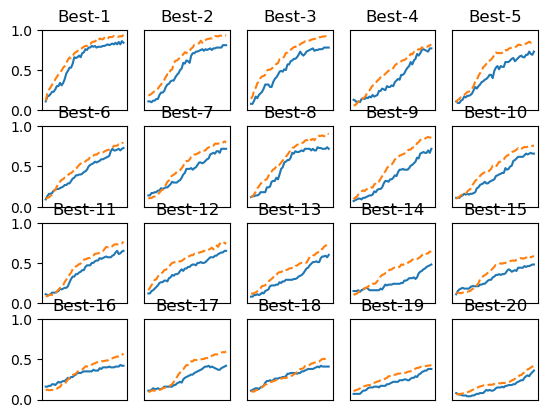

In [9]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 高速化のため訓練データの削減
x_train = x_train[:500]
t_train = t_train[:500]

# 検証データの分離
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# ハイパーパラメータのランダム探索======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 探索したハイパーパラメータの範囲を指定===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# グラフの描画========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()

## 6.6 まとめ

ーーーーー

# ch06/batch_norm_gradient_check.py

In [5]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend

# データの読み込み
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100], output_size=10,
                              use_batchnorm=True)

x_batch = x_train[:1]
t_batch = t_train[:1]

grad_backprop = network.gradient(x_batch, t_batch)
grad_numerical = network.numerical_gradient(x_batch, t_batch)


for key in grad_numerical.keys():
    diff = np.average( np.abs(grad_backprop[key] - grad_numerical[key]) )
    print(key + ":" + str(diff))

W1:0.0
b1:0.0
gamma1:0.0
beta1:0.0
W2:0.0
b2:0.0
gamma2:0.0
beta2:0.05629097639991976
W3:0.0
b3:1.7990357854824612e-07
